In [17]:
import os
import os.path as op
import numpy as np
import pandas as pd

bids_folder= '/shares/zne.uzh/mrenke/ds-stressrisk'
subject_list = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 6]
all_subjects_set = set(subject_list)

sub_array= np.array([int(i) for i in subject_list]) 


In [16]:

group_mapping = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))[['subject','group']].set_index('subject')
group_mapping.head()


,group
subject,
1,0
2,0
3,1
4,1
5,0


In [6]:
from stress_risk.utils.data import Subject
from nilearn.maskers import NiftiMasker
from nilearn import image

def get_vselect_mask(sub, bids_folder):
    roi='NPC_R'
    source_key_vselect = 'encoding_model.cv.denoise.retroicor'
    session1 = 1
    subject = Subject(int(sub), bids_folder=bids_folder)
    ips_mask = subject.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    ips_masker = NiftiMasker(mask_img=ips_mask)
    im_cvr2_fn = op.join(bids_folder, 'derivatives', source_key_vselect, f'sub-{sub}', f'ses-{session1}','func', f'sub-{sub}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(im_cvr2_fn)
    cv_r2 = pd.DataFrame(ips_masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().flatten()
    print(f'Number of voxels: {r2_mask.sum()}')
    return 
    

In [ ]:
key = 'encoding_model.model6.retroicor'
param = 'mu'

difs = []
difs_mean = []
difs_sd = []
for sub in subject_list:
    r2_mask = get_vselect_mask(sub, bids_folder)
    fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
    dat_mu1 = np.load(fn1)[r2_mask]
    fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
    dat_mu2 = np.load(fn2)[r2_mask]
    dif = dat_mu2 - dat_mu1
    difs.append(dif)
    difs_mean.append(dif.mean())
    difs_sd.append(dif.std())


In [23]:
df = pd.DataFrame(np.array(difs_mean), index=sub_array,columns=['mean_mu_dif'])
df.index.name = 'subject'
df = df.join(group_mapping).set_index('group',append=True)

In [25]:
df.head()

,,mean_mu_dif
subject,group,
45,1,3.386431
3,1,-0.678606
23,1,-2.658451
50,0,-2.210681
21,0,-7.525461


[0.55122846]


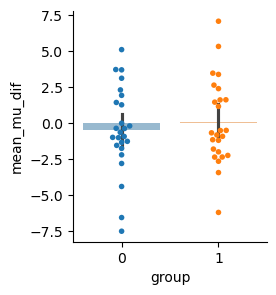

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

y_var = 'mean_mu_dif'
tmp = df.copy()

_, p_value = ttest_ind(tmp.xs(0,0,'group'),tmp.xs(1,0,'group'), equal_var=False)  # Welch's t-test

fig, ax = plt.subplots(1,1, figsize=(2.5,3)) # , sharex=True, sharey=True
fig.suptitle(f'', fontsize=16)
sns.barplot(data=tmp.reset_index(), x ='group', y =y_var ,hue='group', alpha=0.5,legend=False, ax=ax)
sns.swarmplot(data=tmp.reset_index(), y =y_var , x ='group', hue='group',size=4,legend=False, ax=ax)
print(p_value)
sns.despine()

In [38]:
group_mapping

,group
subject,
1,0
2,0
3,1
4,1
5,0
9,0
10,0
12,0
13,1
